***TASK1***

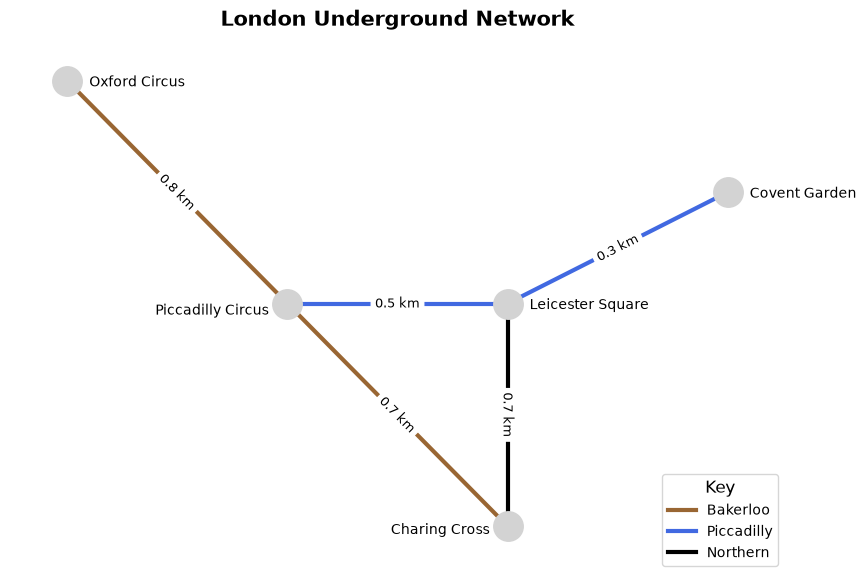

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

G = nx.Graph()

# Stations (Nodes)
stations = [
    "Oxford Circus",
    "Piccadilly Circus",
    "Leicester Square",
    "Covent Garden",
    "Charing Cross"
]

G.add_nodes_from(stations)

# Railway Connections (Edges)
# Format:
# (Station 1, Station 2, Distance in km)

edges = [
    ("Oxford Circus", "Piccadilly Circus", 0.8),
    ("Piccadilly Circus", "Charing Cross", 0.7),
    ("Piccadilly Circus", "Leicester Square", 0.5),
    ("Leicester Square", "Charing Cross", 0.7),
    ("Leicester Square", "Covent Garden", 0.3)
]

for station1, station2, distance in edges:
    G.add_edge(station1, station2, weight=distance)

# Position of each station
pos = {
    "Oxford Circus": (0, 4),
    "Piccadilly Circus": (1, 2),
    "Leicester Square": (2, 2),
    "Covent Garden": (3, 3),
    "Charing Cross": (2, 0)
}

# Create Figure
plt.figure(figsize=(10, 7))

# Draw Stations
nx.draw_networkx_nodes(
    G,
    pos,
    node_color="lightgray",
    node_size=450
)

# Underground Lines
lines = {
    "Bakerloo": {
        "color": "#996633",
        "edges": [
            ("Oxford Circus", "Piccadilly Circus"),
            ("Piccadilly Circus", "Charing Cross")
        ]
    },

    "Piccadilly": {
        "color": "royalblue",
        "edges": [
            ("Piccadilly Circus", "Leicester Square"),
            ("Leicester Square", "Covent Garden")
        ]
    },

    "Northern": {
        "color": "black",
        "edges": [
            ("Leicester Square", "Charing Cross")
        ]
    }
}

# Draw each underground line
for line_name, line in lines.items():

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=line["edges"],
        edge_color=line["color"],
        width=3
    )

edge_labels = {
    (station1, station2): f"{distance} km"
    for station1, station2, distance in edges
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

label_pos = {
    "Oxford Circus": (0.10, 3.95),
    "Piccadilly Circus": (0.40, 1.90),
    "Leicester Square": (2.10, 1.95),
    "Covent Garden": (3.10, 2.95),
    "Charing Cross": (1.47, -0.07)
}

for station, (x, y) in label_pos.items():
    plt.text(
        x,
        y,
        station,
        fontsize=10
    )

for line_name, line in lines.items():

    plt.plot(
        [],
        [],
        color=line["color"],
        linewidth=3,
        label=line_name
    )

plt.legend(
    title="Key",
    loc="lower right",
    frameon=True,
    fontsize=10,
    title_fontsize=12
)

plt.title(
    "London Underground Network",
    fontsize=15,
    weight="bold"
)
                    
plt.axis("off")

plt.show()

***TASK2***

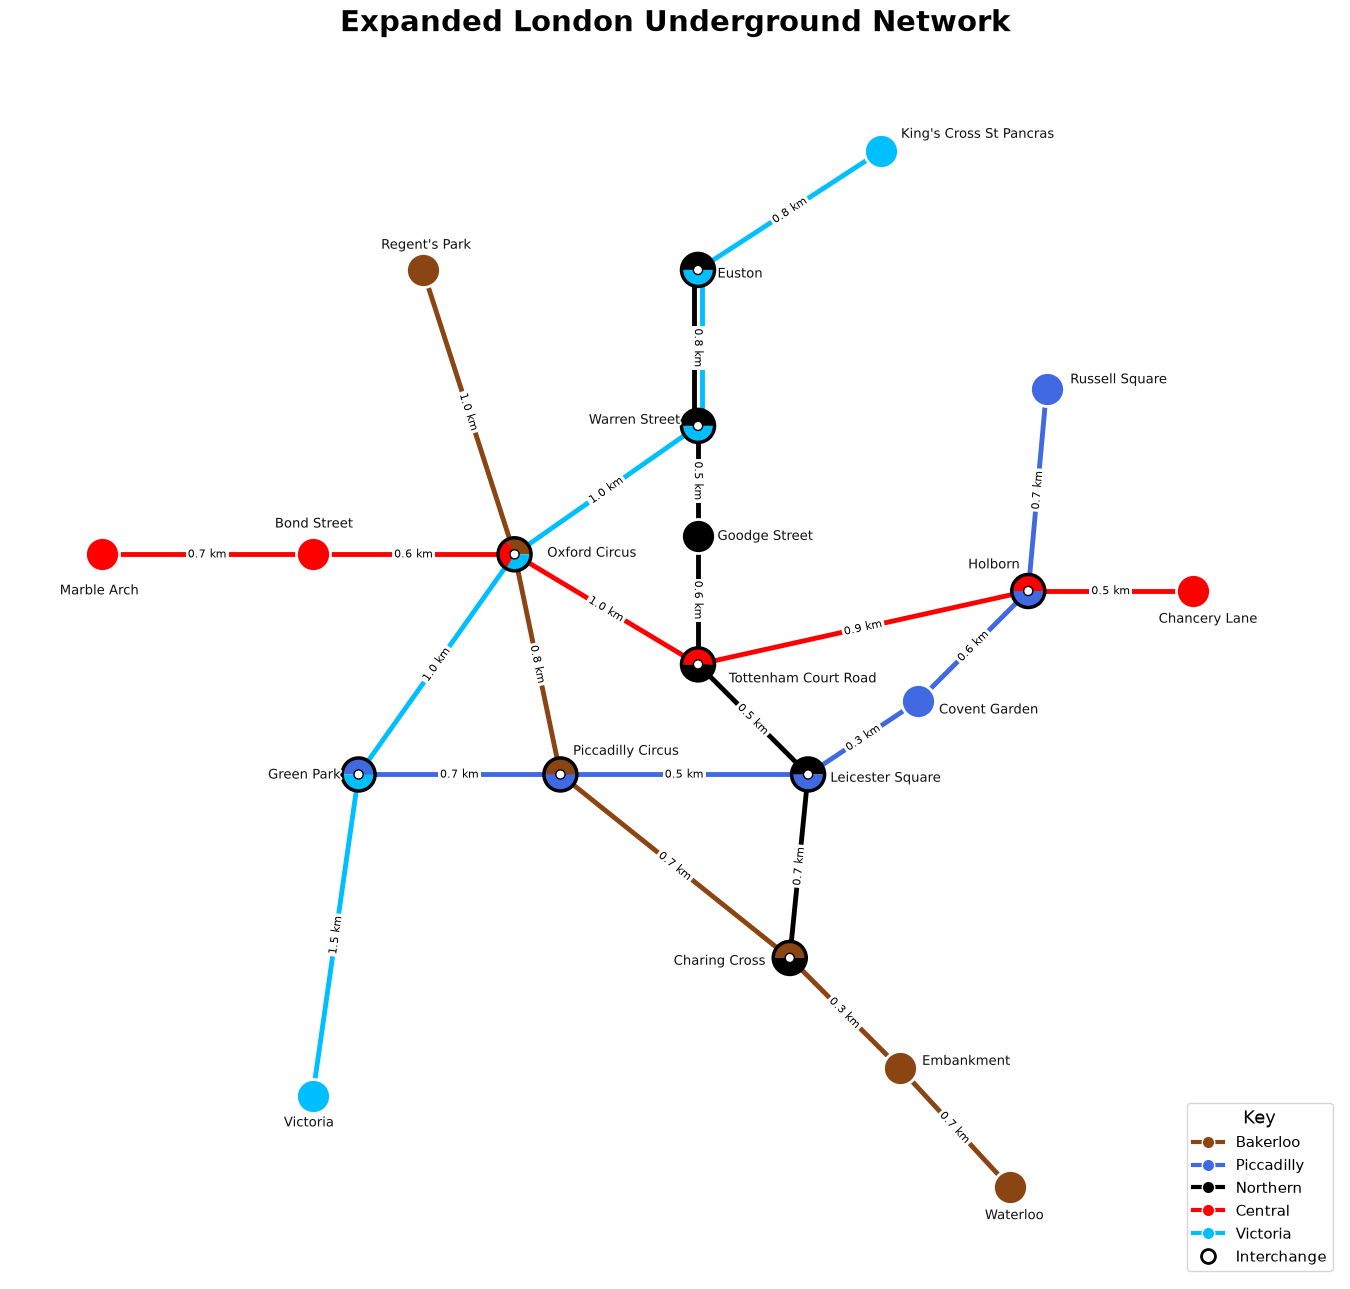

Graph connected: True
Bakerloo: 6 stations
Piccadilly: 6 stations
Northern: 6 stations
Central: 6 stations
Victoria: 6 stations
Interchange stations:
- Charing Cross: Bakerloo, Northern
- Euston: Northern, Victoria
- Green Park: Piccadilly, Victoria
- Holborn: Central, Piccadilly
- Leicester Square: Northern, Piccadilly
- Oxford Circus: Bakerloo, Central, Victoria
- Piccadilly Circus: Bakerloo, Piccadilly
- Tottenham Court Road: Central, Northern
- Warren Street: Northern, Victoria


In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Wedge
import matplotlib.patheffects as path_effects
from collections import defaultdict
import networkx as nx
import numpy as np

# MultiGraph is used because one pair of stations can belong to more than one line.
G = nx.MultiGraph()

# start station, end station, distance, line name, colour
edges = [
    # Bakerloo line
    ("Regent's Park", "Oxford Circus", 1.0, "Bakerloo", "saddlebrown"),
    ("Oxford Circus", "Piccadilly Circus", 0.8, "Bakerloo", "saddlebrown"),
    ("Piccadilly Circus", "Charing Cross", 0.7, "Bakerloo", "saddlebrown"),
    ("Charing Cross", "Embankment", 0.3, "Bakerloo", "saddlebrown"),
    ("Embankment", "Waterloo", 0.7, "Bakerloo", "saddlebrown"),

    # Piccadilly line
    ("Green Park", "Piccadilly Circus", 0.7, "Piccadilly", "royalblue"),
    ("Piccadilly Circus", "Leicester Square", 0.5, "Piccadilly", "royalblue"),
    ("Leicester Square", "Covent Garden", 0.3, "Piccadilly", "royalblue"),
    ("Covent Garden", "Holborn", 0.6, "Piccadilly", "royalblue"),
    ("Holborn", "Russell Square", 0.7, "Piccadilly", "royalblue"),

    # Northern line
    ("Euston", "Warren Street", 0.8, "Northern", "black"),
    ("Warren Street", "Goodge Street", 0.5, "Northern", "black"),
    ("Goodge Street", "Tottenham Court Road", 0.6, "Northern", "black"),
    ("Tottenham Court Road", "Leicester Square", 0.5, "Northern", "black"),
    ("Leicester Square", "Charing Cross", 0.7, "Northern", "black"),

    # Central line
    ("Marble Arch", "Bond Street", 0.7, "Central", "red"),
    ("Bond Street", "Oxford Circus", 0.6, "Central", "red"),
    ("Oxford Circus", "Tottenham Court Road", 1.0, "Central", "red"),
    ("Tottenham Court Road", "Holborn", 0.9, "Central", "red"),
    ("Holborn", "Chancery Lane", 0.5, "Central", "red"),

    # Victoria line
    ("King's Cross St Pancras", "Euston", 0.8, "Victoria", "deepskyblue"),
    ("Euston", "Warren Street", 0.8, "Victoria", "deepskyblue"),
    ("Warren Street", "Oxford Circus", 1.0, "Victoria", "deepskyblue"),
    ("Oxford Circus", "Green Park", 1.0, "Victoria", "deepskyblue"),
    ("Green Park", "Victoria", 1.5, "Victoria", "deepskyblue"),
]

for start, end, distance, line, colour in edges:
    G.add_edge(
        start,
        end,
        distance=distance,
        line=line,
        colour=colour,
    )

# Manual station positions
pos = {
    "Regent's Park": (-3.0, 5.5),
    "Oxford Circus": (-2.0, 2.4),
    "Piccadilly Circus": (-1.5, 0.0),
    "Charing Cross": (1.0, -2.0),
    "Embankment": (2.2, -3.2),
    "Waterloo": (3.4, -4.5),
    "Green Park": (-3.7, 0),
    "Leicester Square": (1.2, 0.0),
    "Covent Garden": (2.4, 0.8),
    "Holborn": (3.6, 2.0),
    "Russell Square": (3.8, 4.2),
    "Euston": (0.0, 5.5),
    "Warren Street": (0.0, 3.8),
    "Goodge Street": (0.0, 2.6),
    "Tottenham Court Road": (0.0, 1.2),
    "Marble Arch": (-6.5, 2.4),
    "Bond Street": (-4.2, 2.4),
    "Chancery Lane": (5.4, 2.0),
    "King's Cross St Pancras": (2.0, 6.8),
    "Victoria": (-4.2, -3.5),
}

# Station label placement in POINTS, not map coordinates.
# Using offset points keeps every name equally close to its node,
# even when the map size or axis limits change.
# Format: (offset_x, offset_y, horizontal alignment, vertical alignment)
label_config = {
    "Regent's Park": (-30, 13, "left", "bottom"),
    "Oxford Circus": (55, -4, "center", "bottom"),
    "Piccadilly Circus": (85, 17, "right", "center"),
    "Charing Cross": (-19, 3, "right", "top"),
    "Embankment": (16, 0, "left", "bottom"),
    "Waterloo": (-18, -15, "left", "top"),
    "Green Park": (-14, 5, "right", "top"),
    "Leicester Square": (16, 2, "left", "top"),
    "Covent Garden": (15, -1, "left", "top"),
    "Holborn": (-25, 14, "center", "bottom"),
    "Russell Square": (17, 2, "left", "bottom"),
    "Euston": (14, -3, "left", "center"),
    "Warren Street": (-15, 4, "right", "center"),
    "Goodge Street": (14, 0, "left", "center"),
    "Tottenham Court Road": (126, -5, "right", "top"),
    "Marble Arch": (25, -26, "right", "center"),
    "Bond Street": (0, 17, "center", "bottom"),
    "Chancery Lane": (-25, -20, "left", "center"),
    "King's Cross St Pancras": (14, 7, "left", "bottom"),
    "Victoria": (15, -15, "right", "top"),
}

# One consistent style for every station name.
FONT_FAMILY = "DejaVu Sans"
STATION_FONT_SIZE = 9.5
STATION_FONT_WEIGHT = "normal"
STATION_FONT_COLOUR = "#111111"

# Each line has its own colour, while every normal station uses a circle.
line_information = {
    "Bakerloo": {"colour": "saddlebrown", "marker": "o"},   # circle
    "Piccadilly": {"colour": "royalblue", "marker": "o"},  # circle
    "Northern": {"colour": "black", "marker": "o"},        # circle
    "Central": {"colour": "red", "marker": "o"},           # circle
    "Victoria": {"colour": "deepskyblue", "marker": "o"}, # circle
}

# Find all lines used by every station.
station_lines = defaultdict(set)
for start, end, distance, line, colour in edges:
    station_lines[start].add(line)
    station_lines[end].add(line)

# A station is an interchange when two or more lines meet there.
interchange_stations = {
    station: lines
    for station, lines in station_lines.items()
    if len(lines) >= 2
}

# Group repeated station pairs, for example Euston-Warren Street.
edge_to_records = defaultdict(list)
for edge in edges:
    start, end, distance, line, colour = edge
    pair = tuple(sorted((start, end)))
    edge_to_records[pair].append(edge)

fig, ax = plt.subplots(figsize=(18, 13))

# Draw edges. Shared sections are slightly separated so both colours remain visible.
for pair, records in edge_to_records.items():
    number_of_lines = len(records)

    for index, (start, end, distance, line, colour) in enumerate(records):
        x1, y1 = pos[start]
        x2, y2 = pos[end]

        dx = x2 - x1
        dy = y2 - y1
        edge_length = np.hypot(dx, dy)

        perpendicular_x = -dy / edge_length
        perpendicular_y = dx / edge_length

        if number_of_lines > 1:
            offset = (index - (number_of_lines - 1) / 2) * 0.08
        else:
            offset = 0

        ax.plot(
            [x1 + perpendicular_x * offset, x2 + perpendicular_x * offset],
            [y1 + perpendicular_y * offset, y2 + perpendicular_y * offset],
            color=colour,
            linewidth=3.5,
            solid_capstyle="round",
            zorder=1,
        )

# Draw normal stations as circles using the colour assigned to their line.
for line_name, style in line_information.items():
    normal_stations = [
        station
        for station, lines in station_lines.items()
        if len(lines) == 1 and line_name in lines
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=normal_stations,
        node_shape=style["marker"],
        node_size=600,
        node_color=style["colour"],
        edgecolors="white",
        linewidths=2,
        ax=ax,
    )

# Draw interchange stations as multi-colour circular symbols.
for station, lines in interchange_stations.items():
    x, y = pos[station]
    sorted_lines = sorted(lines)
    radius = 0.18
    angle_per_line = 360 / len(sorted_lines)

    for index, line_name in enumerate(sorted_lines):
        coloured_section = Wedge(
            center=(x, y),
            r=radius,
            theta1=index * angle_per_line,
            theta2=(index + 1) * angle_per_line,
            facecolor=line_information[line_name]["colour"],
            edgecolor="none",
            zorder=4,
        )
        ax.add_patch(coloured_section)

    outer_circle = Circle(
        (x, y),
        radius=radius,
        facecolor="none",
        edgecolor="black",
        linewidth=2.5,
        zorder=5,
    )
    ax.add_patch(outer_circle)

    inner_circle = Circle(
        (x, y),
        radius=0.05,
        facecolor="white",
        edgecolor="black",
        linewidth=1,
        zorder=6,
    )
    ax.add_patch(inner_circle)

# Draw every station name with exactly the same style and a small,
# uniform physical gap from its node.
for station, station_position in pos.items():
    offset_x, offset_y, horizontal_alignment, vertical_alignment = (
        label_config[station]
    )

    station_label = ax.annotate(
        station,
        xy=station_position,
        xycoords="data",
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        fontsize=STATION_FONT_SIZE,
        fontfamily=FONT_FAMILY,
        fontweight=STATION_FONT_WEIGHT,
        color=STATION_FONT_COLOUR,
        horizontalalignment=horizontal_alignment,
        verticalalignment=vertical_alignment,
        annotation_clip=False,
        zorder=10,
    )

    # Thin white outline keeps labels readable near coloured lines.
    station_label.set_path_effects([
        path_effects.withStroke(linewidth=2.5, foreground="white")
    ])

# Draw one distance label for every station pair.
for pair, records in edge_to_records.items():
    start, end, distance, line, colour = records[0]

    x1, y1 = pos[start]
    x2, y2 = pos[end]

    middle_x = (x1 + x2) / 2.0
    middle_y = (y1 + y2) / 2.0

    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))

    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    ax.text(
        middle_x,
        middle_y,
        f"{distance} km",
        fontsize=8,
        rotation=angle,
        rotation_mode="anchor",
        horizontalalignment="center",
        verticalalignment="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "pad": 1.5,
            "alpha": 1.0,
        },
        zorder=9,
    )

# Create the Key using the colour of each underground line.
key = []

for line_name, style in line_information.items():
    key.append(
        Line2D(
            [0],
            [0],
            color=style["colour"],
            linewidth=3,
            marker=style["marker"],
            markersize=9,
            markerfacecolor=style["colour"],
            markeredgecolor="white",
            label=line_name,
        )
    )

key.append(
    Line2D(
        [0],
        [0],
        color="none",
        marker="o",
        markersize=10,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=2,
        label="Interchange",
    )
)

ax.legend(
    handles=key,
    title="Key",
    fontsize=11,
    title_fontsize=13,
    loc="lower right",
    frameon=True,
)

ax.set_title(
    "Expanded London Underground Network",
    fontsize=21,
    fontweight="bold",
    pad=20,
)

ax.axis("off")
ax.set_xlim(-7.5, 7.0)
ax.set_ylim(-5.5, 7.8)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Validation for Task 2
print("Graph connected:", nx.is_connected(nx.Graph(G)))

for line_name in line_information:
    stations_on_line = {
        station
        for start, end, distance, line, colour in edges
        if line == line_name
        for station in (start, end)
    }
    print(f"{line_name}: {len(stations_on_line)} stations")

print("Interchange stations:")
for station, lines in sorted(interchange_stations.items()):
    print(f"- {station}: {', '.join(sorted(lines))}")

***TASK3***

In [3]:
distances = np.array(
    [
        edge_data["distance"]
        for _, _, _, edge_data in G.edges(keys=True, data=True)
    ],
    dtype=float,
)

total_network_length = np.sum(distances)
average_station_distance = np.mean(distances)
distance_standard_deviation = np.std(distances, ddof=0)

print("Transport Network Statistics")
print(f"Number of transport connections: {len(distances)}")
print(f"Total length of the transport network: {total_network_length:.2f} km")
print(f"Average distance between stations: {average_station_distance:.3f} km")
print(
    "Standard deviation of distances between stations: "
    f"{distance_standard_deviation:.3f} km"
)

Transport Network Statistics
Number of transport connections: 25
Total length of the transport network: 18.20 km
Average distance between stations: 0.728 km
Standard deviation of distances between stations: 0.251 km
